In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import pandas as pd
import numpy as np
import scipy.sparse as sp
import json
import os
import glob

/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

figure_params = {
    'dpi': 300, 
    'bbox_inches': 'tight', 
    'format': 'svg', 
    'transparent': True
}

plt.rcParams.update({
    "text.usetex": False,
    "svg.fonttype": 'none'
})

figures_dir = '/ix/djishnu/Akanksha/datasets/ERCC1_KO/figures'

In [3]:
adata = sc.read_h5ad('/ix/djishnu/Akanksha/datasets/ERCC1_KO/objects/objects/adata_harmony_celloracle_compatible_v2.h5ad')

/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/anndata/_core/anndata.py:1792: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [4]:
adata

AnnData object with n_obs × n_vars = 86672 × 3000
    obs: 'sample_id', 'cell_type', 'condition', 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_mt_cb', 'log1p_total_counts_mt_cb', 'pct_counts_mt_cb', 'total_counts_ribo_cb', 'log1p_total_counts_ribo_cb', 'pct_counts_ribo_cb', 'total_counts_hb_cb', 'log1p_total_counts_hb_cb', 'pct_counts_hb_cb', 'n_genes', 'sex', 'batch', '_scvi_batch', '_scvi_labels', 'C_scANVI'
    var: 'hb', 'ribo', 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'dispersions', 'dispersions_norm'
    uns: 'C_scANVI_colors', '_scvi_manager_uuid', '_scvi_uui

In [5]:
adata.obs['C_scANVI'].value_counts()

C_scANVI
Fast IIX         34128
Fast IIB         33378
MTJ               5034
EC                3263
FAPs              2830
Skeleton MuSc     2077
Pericyte          1970
Tendon            1958
NMJ               1066
Macrophages        968
Name: count, dtype: int64

### Re-annotate the cell-populations to separate out the type2a population

In [6]:
adata_full = adata.raw.to_adata()
adata_full.obs = adata.obs.copy()
adata_full.obs_names_make_unique()

# Look at the actual non-zero values, not the top-left corner
import numpy as np
from scipy import sparse
X = adata_full.X
nz = X.data[:10000] if sparse.issparse(X) else X[X != 0][:10000]
print("non-zero sample:", nz[:20])
print("min / max / mean:", nz.min(), nz.max(), nz.mean())

is_counts = np.allclose(nz, nz.astype(int))
print(f"raw.X looks like {'counts' if is_counts else 'log-normalized'}")

if is_counts:
    sc.pp.normalize_total(adata_full, target_sum=1e4)
    sc.pp.log1p(adata_full)

non-zero sample: [1.20294712 1.20294712 1.73339425 1.73339425 2.70668238 1.20294712
 1.20294712 2.97753414 2.85125045 2.85125045 1.73339425 1.20294712
 3.08964353 2.07815927 2.70668238 1.20294712 1.20294712 1.20294712
 2.33405125 1.20294712]
min / max / mean: 1.0257651570429829 7.200938873661968 1.6548693688666176
raw.X looks like log-normalized


/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/anndata/_core/anndata.py:1792: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [7]:
# Pool of cells eligible for fiber-type reassignment
fast_pool = adata.obs["C_scANVI"].isin(["Fast IIX", "Fast IIB"])
# (add "Fast IIA" too if you have a native cluster — your crosstab doesn't show one)

# Recompute dominant myosin only inside that pool
expr = sc.get.obs_df(adata_full, ["Myh2", "Myh1", "Myh4", "Myh7"])
expr.index = adata.obs_names

detected = (expr.max(axis=1) > 0.5) & fast_pool
winner = expr.idxmax(axis=1)
label_map = {"Myh2": "IIA", "Myh1": "IIX", "Myh4": "IIB", "Myh7": "I"}

# Start from the original annotation, overwrite only the eligible cells
fiber_call = adata.obs["C_scANVI"].astype(str).copy()
fiber_call.loc[detected] = winner[detected].map(label_map).map(
    {"IIA": "Fast IIA", "IIX": "Fast IIX", "IIB": "Fast IIB", "I": "Fast I"}
).values

adata.obs["fiber_call"] = pd.Categorical(fiber_call)

print(pd.crosstab(adata.obs["C_scANVI"], adata.obs["fiber_call"]))

fiber_call       EC  FAPs  Fast I  Fast IIA  Fast IIB  Fast IIX   MTJ  \
C_scANVI                                                                
EC             3263     0       0         0         0         0     0   
FAPs              0  2830       0         0         0         0     0   
Fast IIB          0     0       0        26     32845       507     0   
Fast IIX          0     0      11      3388      9417     21312     0   
MTJ               0     0       0         0         0         0  5034   
Macrophages       0     0       0         0         0         0     0   
NMJ               0     0       0         0         0         0     0   
Pericyte          0     0       0         0         0         0     0   
Skeleton MuSc     0     0       0         0         0         0     0   
Tendon            0     0       0         0         0         0     0   

fiber_call     Macrophages   NMJ  Pericyte  Skeleton MuSc  Tendon  
C_scANVI                                               

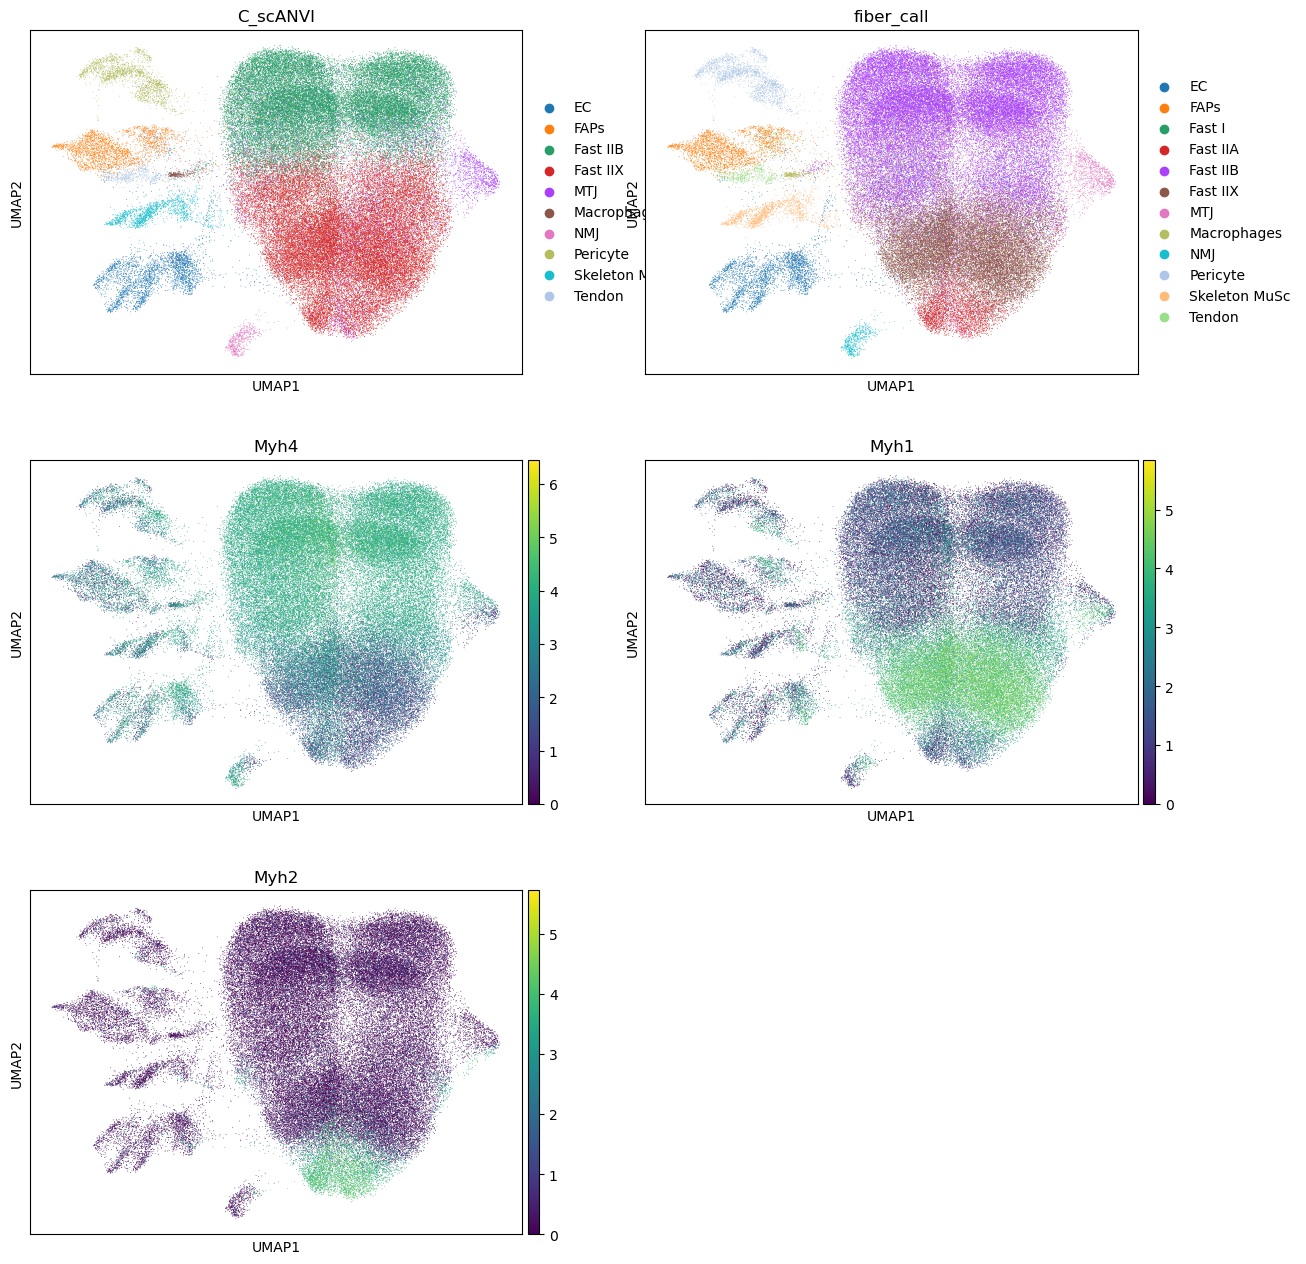

In [8]:
sc.pl.umap(adata, color=["C_scANVI", "fiber_call", 'Myh4', 'Myh1', 'Myh2'], ncols=2)

### Inspect the clustering

In [10]:
# 1. Rename and drop Fast I (only ~19 cells, likely noise in mouse TA)
adata.obs = adata.obs.rename(columns={"fiber_call": "re_annot"})
keep = adata.obs["re_annot"] != "Fast I"
adata_re = adata[keep].copy()

# remove the unused category so it doesn't show up in legends
adata_re.obs["re_annot"] = adata_re.obs["re_annot"].cat.remove_unused_categories()
print(adata_re.obs["re_annot"].value_counts())

re_annot
Fast IIB         42262
Fast IIX         21819
MTJ               5034
Fast IIA          3414
EC                3263
FAPs              2830
Skeleton MuSc     2077
Pericyte          1970
Tendon            1958
NMJ               1066
Macrophages        968
Name: count, dtype: int64


/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/anndata/_core/anndata.py:1792: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
sc.pp.neighbors(adata_re, use_rep="X_pca", n_neighbors=30)
sc.tl.umap(adata_re, min_dist=0.3, spread=1.0)
sc.tl.leiden(adata_re, resolution=0.6, key_added="leiden_re")

sc.pl.umap(
    adata_re,
    color=["re_annot", "C_scANVI", "leiden_re", "Myh2", "Myh1", "Myh4"],
    ncols=3, vmax="p99",
)

/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/scanpy/neighbors/__init__.py:423: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if "X_diffmap" in adata.obsm_keys():


In [ ]:
adata_sex = adata[adata.obs['sex'] == 'F']

In [ ]:
adata_sex.obs

In [ ]:
adata_plot = adata_sex[adata_sex.obs['C_scANVI'].isin(['Fast IIX', 'Fast IIB'])]

In [ ]:
# find var_names containing 'Sod'
adata_plot.var_names[adata_plot.var_names.str.contains('Myh2')] #not highly expressed so got filtered out in pre-processing

In [ ]:
adata_plot.obs

## gene expression related plots

In [ ]:
sc.pl.embedding(adata_sex, basis='umap', color='C_scANVI', show=False)
# plt.savefig(f'{figures_dir}/Male_2x_2b_cell_type.svg',
#               bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
adata_sex.X.min(), adata_plot.X.max()

In [ ]:
sc.pl.embedding(adata_sex, basis='umap',
                  color=['Myh2'],
                  vmin=0, vmax='p99', show=False)
# plt.savefig(f'{figures_dir}/Male_2x_2b_Myh1.svg',
#               bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
sc.pl.embedding(adata_sex, basis='umap',
                  color=['Tnnt2'],show=False)
# plt.savefig(f'{figures_dir}/Male_2x_2b_Tnnt2.svg',
#               bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
sc.pl.dotplot(adata, ['Myh1', 'Tnnt2'], groupby='condition', show=False)
plt.savefig(f'{figures_dir}/Female_Myh1_Tnnt2_dotplot.svg',
              bbox_inches='tight', dpi=300)
plt.show()

### Cell proportions
#### 1. Sankey plot for 4 subsets where the width of the flow shows how much of that category's population maps to the different cell types
#### 2. Pie charts to show cell-type population differences between male and female

In [ ]:
#df = adata_whole.obs.groupby(['sex_condition', 'C_scANVI']).size().reset_index(name='count')
df = adata_whole.obs.groupby(['sex', 'C_scANVI']).size().reset_index(name='count')

# rename sex_condition to group
# df = df.rename(columns={'sex_condition': 'group'})
df = df.rename(columns={'sex': 'group'})
# rename C_scANVI to cell_type
df = df.rename(columns={'C_scANVI': 'cell_type'})
display(df.head())

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
import matplotlib.patches as patches
import pandas as pd

# ── CONFIG ──────────────────────────────────────────────────────────────────
LEFT_COL   = 'sex'
RIGHT_COL  = 'C_scANVI'
LEFT_ORDER = ['F', 'M']

COLOR_MAP = {
    'F': '#e8a0a0',
    'M': '#5dbdb2',
}

# scanpy cell type colors — auto-pulled or define manually
cell_type_colors = dict(zip(
    adata_whole.obs[RIGHT_COL].cat.categories,
    adata_whole.uns.get(f'{RIGHT_COL}_colors', 
        plt.cm.tab20.colors[:len(adata_whole.obs[RIGHT_COL].cat.categories)])
))

# ── DATA ────────────────────────────────────────────────────────────────────
df = adata_whole.obs.groupby([LEFT_COL, RIGHT_COL]).size().reset_index(name='count')

left_groups  = LEFT_ORDER
right_groups = adata_whole.obs[RIGHT_COL].cat.categories.tolist()

# Normalize counts within each left group (proportions)
totals = df.groupby(LEFT_COL)['count'].transform('sum')
df['prop'] = df['count'] / totals

# ── LAYOUT ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

BAR_W  = 0.03
GAP    = 0.008
X_LEFT = 0.28   # wider left margin for labels
X_RIGHT= 0.58   # closer to left bar
ALPHA  = 0.4

def calc_positions(groups, counts_dict, x_pos, bar_w):
    """Return {group: (y_bottom, y_top)} for stacked bars."""
    total = sum(counts_dict[g] for g in groups)
    positions = {}
    y = 0.05
    for g in groups:
        h = (counts_dict[g] / total) * 0.9
        positions[g] = (y, y + h)
        y += h + GAP * 0.5
    return positions

# Totals for sizing
left_totals  = df.groupby(LEFT_COL)['count'].sum().to_dict()
right_totals = df.groupby(RIGHT_COL)['count'].sum().to_dict()

left_pos  = calc_positions(left_groups,  left_totals,  X_LEFT,  BAR_W)
right_pos = calc_positions(right_groups, right_totals, X_RIGHT, BAR_W)

# ── DRAW FLOWS ──────────────────────────────────────────────────────────────
# Track current fill position for each bar
left_fill  = {g: left_pos[g][0]  for g in left_groups}
right_fill = {g: right_pos[g][0] for g in right_groups}

left_total_sum = sum(left_totals.values())

for _, row in df.sort_values([LEFT_COL, RIGHT_COL]).iterrows():
    lg, rg, cnt = row[LEFT_COL], row[RIGHT_COL], row['count']

    l_total = left_totals[lg]
    r_total = right_totals[rg]
    l_span  = (left_pos[lg][1] - left_pos[lg][0])
    r_span  = (right_pos[rg][1] - right_pos[rg][0])

    lh = (cnt / l_total) * l_span
    rh = (cnt / r_total) * r_span

    ly0 = left_fill[lg]
    ry0 = right_fill[rg]
    ly1 = ly0 + lh
    ry1 = ry0 + rh

    left_fill[lg]  += lh
    right_fill[rg] += rh

    # Bezier curve path
    verts = [
        (X_LEFT + BAR_W, ly0),
        ((X_LEFT + BAR_W + X_RIGHT) / 2, ly0),
        ((X_LEFT + BAR_W + X_RIGHT) / 2, ry0),
        (X_RIGHT, ry0),
        (X_RIGHT, ry1),
        ((X_LEFT + BAR_W + X_RIGHT) / 2, ry1),
        ((X_LEFT + BAR_W + X_RIGHT) / 2, ly1),
        (X_LEFT + BAR_W, ly1),
        (X_LEFT + BAR_W, ly0),
    ]
    codes = [
        Path.MOVETO,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.LINETO,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.CLOSEPOLY,
    ]
    path  = Path(verts, codes)
    patch = patches.PathPatch(
        path,
        facecolor=COLOR_MAP[lg],
        edgecolor='none',
        alpha=ALPHA,
        zorder=1
    )
    ax.add_patch(patch)

# ── DRAW BARS ────────────────────────────────────────────────────────────────
for g in left_groups:
    y0, y1 = left_pos[g]
    ax.add_patch(plt.Rectangle(
        (X_LEFT, y0), BAR_W, y1 - y0,
        color=COLOR_MAP[g], zorder=2, linewidth=0
    ))
    ax.text(X_LEFT - 0.01, (y0 + y1) / 2, g,
            ha='right', va='center', fontsize=10, fontweight='bold')

for g in right_groups:
    y0, y1 = right_pos[g]
    ax.add_patch(plt.Rectangle(
        (X_RIGHT, y0), BAR_W, y1 - y0,
        color=cell_type_colors.get(g, '#aaaaaa'), zorder=2, linewidth=0
    ))
    ax.text(X_RIGHT + BAR_W + 0.01, (y0 + y1) / 2, g,
            ha='left', va='center', fontsize=9)

plt.title('Cell Proportion', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/figures/sankey_M_F_to_cell_type.pdf', bbox_inches='tight', dpi=300)
# plt.savefig('sankey_moscot_style.png', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# Set the figures directory first
sc.settings.figdir = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/figures'

# Then save= is just the filename suffix
sc.pl.umap(adata_whole, color=['C_scANVI'], show=False, save='_C_scANVI.pdf')